In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip uninstall -y transformers


In [ ]:
!pip install --no-cache-dir transformers==4.51.3


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 266.5 MB/s eta 0:00:00


In [ ]:
from transformers import TrainingArguments
help(TrainingArguments)

Help on class TrainingArguments in module transformers.training_args:

class TrainingArguments(builtins.object)
 |  TrainingArguments(output_dir: Optional[str] = None, overwrite_output_dir: bool = False, do_train: bool = False, do_eval: bool = False, do_predict: bool = False, eval_strategy: Union[transformers.trainer_utils.IntervalStrategy, str] = 'no', prediction_loss_only: bool = False, per_device_train_batch_size: int = 8, per_device_eval_batch_size: int = 8, per_gpu_train_batch_size: Optional[int] = None, per_gpu_eval_batch_size: Optional[int] = None, gradient_accumulation_steps: int = 1, eval_accumulation_steps: Optional[int] = None, eval_delay: Optional[float] = 0, torch_empty_cache_steps: Optional[int] = None, learning_rate: float = 5e-05, weight_decay: float = 0.0, adam_beta1: float = 0.9, adam_beta2: float = 0.999, adam_epsilon: float = 1e-08, max_grad_norm: float = 1.0, num_train_epochs: float = 3.0, max_steps: int = -1, lr_scheduler_type: Union[transformers.trainer_utils.Sch

In [ ]:
!pip install transformers datasets vaderSentiment pandas scikit-learn matplotlib seaborn
!pip install --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 18.5 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import classification_report, confusion_matrix
import torch
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset


In [ ]:
import os

drive_root = "/content/drive/MyDrive"
lyrics_jl_path = os.path.join(drive_root, "lyrics.jl")
mxm_db_path = os.path.join(drive_root, "mxm_dataset.db")
msd_metadata_csv_path = os.path.join(drive_root, "million_song_subset_metadata.csv")

lyrics_csv_path = os.path.join(drive_root, "lyrics_dataset.csv")
mxm_csv_path = os.path.join(drive_root, "mxm_dataset.csv")

In [ ]:
import json
import pandas as pd

data = []
bad_lines = 0

with open(lyrics_jl_path, 'r', encoding='utf-8') as f:
    for line in f:
        try:
            data.append(json.loads(line))
        except json.JSONDecodeError:
            bad_lines += 1
            continue

df_lyrics = pd.DataFrame(data)
df_lyrics.to_csv(lyrics_csv_path, index=False)
print(f" Saved lyrics dataset to: {lyrics_csv_path}")
print(f" Skipped {bad_lines} malformed lines.")

 Saved lyrics dataset to: /content/drive/MyDrive/lyrics_dataset.csv
 Skipped 1 malformed lines.


In [ ]:
df_lyrics

,song,lyrics
0,Kendrick-lamar-swimming-pools-drank-lyrics,\n\n[Produced by T-Minus]\n\n[Intro]\nPour up ...
1,Kendrick-lamar-money-trees-lyrics,\n\n[Produced by DJ Dahi]\n\n[Verse 1: Kendric...
2,Kendrick-lamar-xxx-lyrics,"\n\n[Intro: Bēkon & Kid Capri]\nAmerica, God b..."
3,A-ap-rocky-fuckin-problems-lyrics,"\n\n[Chorus: 2 Chainz, Drake & Both (A$AP Rock..."
4,Kendrick-lamar-dna-lyrics,"\n\n[Verse 1]\nI got, I got, I got, I got—\nLo..."
...,...,...
269,J-cole-and-kendrick-lamar-shock-the-world-lyrics,\n\n[Verse 1: J. Cole]\nLife make a nigga wann...
270,The-game-murder-lyrics,\n\n[Verse 1: Game]\nStarin’ at Marilyn Monroe...
271,Kendrick-lamar-phone-home-lyrics,\n\n[Produced by Cool and Dre]\n\n[Verse 1: Ke...
272,Xv-textbook-stuff-lyrics,"\n\n[Hook]\nThere, there, baby\nIt's just text..."


In [ ]:
import sqlite3

conn = sqlite3.connect(mxm_db_path)
df_mxm = pd.read_sql("SELECT * FROM lyrics", conn)
df_mxm.to_csv(mxm_csv_path, index=False)
conn.close()
print("Saved:", mxm_csv_path)

Saved: /content/drive/MyDrive/mxm_dataset.csv


In [ ]:
print("Lyrics columns:", df_lyrics.columns.tolist())
print("MXM columns:", df_mxm.columns.tolist())

Lyrics columns: ['song', 'lyrics']
MXM columns: ['track_id', 'mxm_tid', 'word', 'count', 'is_test']


In [ ]:
df_mxm

,track_id,mxm_tid,word,count,is_test
0,TRAAAAV128F421A322,4623710,i,6,0
1,TRAAAAV128F421A322,4623710,the,4,0
2,TRAAAAV128F421A322,4623710,you,2,0
3,TRAAAAV128F421A322,4623710,to,2,0
4,TRAAAAV128F421A322,4623710,and,5,0
...,...,...,...,...,...
19045327,TRZZZZD128F4236844,2466899,easili,1,1
19045328,TRZZZZD128F4236844,2466899,disast,1,1
19045329,TRZZZZD128F4236844,2466899,frown,1,1
19045330,TRZZZZD128F4236844,2466899,teas,1,1


In [ ]:
df_mxm_clean = df_mxm[df_mxm['is_test'] == 0].copy()
from collections import defaultdict
track_lyrics = defaultdict(list)

for _, row in df_mxm_clean.iterrows():
    word = row['word']
    count = int(row['count'])
    track_id = row['track_id']
    track_lyrics[track_id].extend([word] * count)

reconstructed = {
    'track_id': [],
    'lyrics': []
}

for tid, words in track_lyrics.items():
    reconstructed['track_id'].append(tid)
    reconstructed['lyrics'].append(' '.join(words))

df_reconstructed = pd.DataFrame(reconstructed)
df_reconstructed.to_csv("/content/drive/MyDrive/lyrics_musicx.csv", index=False)
df_reconstructed.head()

,track_id,lyrics
0,TRAAAAV128F421A322,i i i i i i the the the the you you to to and ...
1,TRAAABD128F429CF47,i i i i i i i i i i you you you you you you yo...
2,TRAAAED128E0783FAB,i i i i i i i i i i i i i i i i i i i i i i i ...
3,TRAAAEF128F4273421,i i i i i the the the the you you you to to an...
4,TRAAAEW128F42930C0,i i i i to to to to to and and and and and and...


In [ ]:
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [ ]:
analyzer = SentimentIntensityAnalyzer()

def get_emotion(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df_reconstructed['emotion'] = df_reconstructed['lyrics'].apply(get_emotion)
df_reconstructed.to_csv('/content/drive/MyDrive/emotion_output.csv', index=False)

df_reconstructed[['track_id', 'emotion']].head()

,track_id,emotion
0,TRAAAAV128F421A322,positive
1,TRAAABD128F429CF47,positive
2,TRAAAED128E0783FAB,positive
3,TRAAAEF128F4273421,positive
4,TRAAAEW128F42930C0,negative


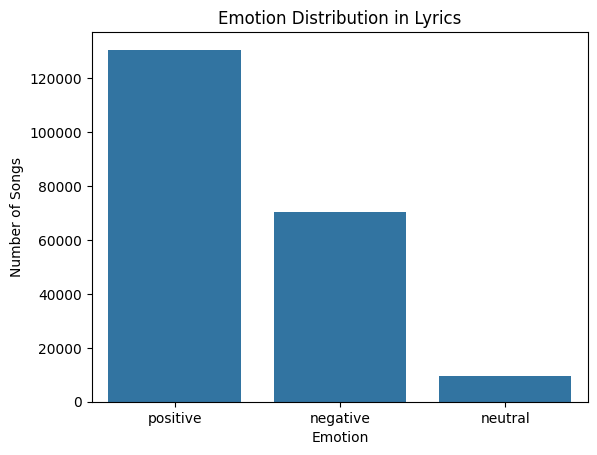

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

emotion_counts = df_reconstructed['emotion'].value_counts()

sns.barplot(x=emotion_counts.index, y=emotion_counts.values)
plt.title("Emotion Distribution in Lyrics")
plt.xlabel("Emotion")
plt.ylabel("Number of Songs")
plt.show()

In [ ]:
import numpy as np

genres = ['pop', 'rock', 'hiphop']
np.random.seed(42)

df_reconstructed['genre'] = np.random.choice(genres, size=len(df_reconstructed))

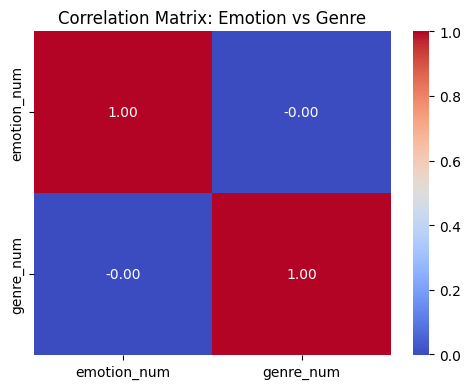

In [ ]:
emotion_map = {'positive': 1, 'neutral': 0, 'negative': -1}
genres = ['pop', 'rock', 'hiphop']
genre_map = {g: i for i, g in enumerate(genres)}

df_reconstructed['emotion_num'] = df_reconstructed['emotion'].map(emotion_map)
df_reconstructed['genre_num'] = df_reconstructed['genre'].map(genre_map)

corr = df_reconstructed[['emotion_num', 'genre_num']].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix: Emotion vs Genre")
plt.tight_layout()
plt.show()


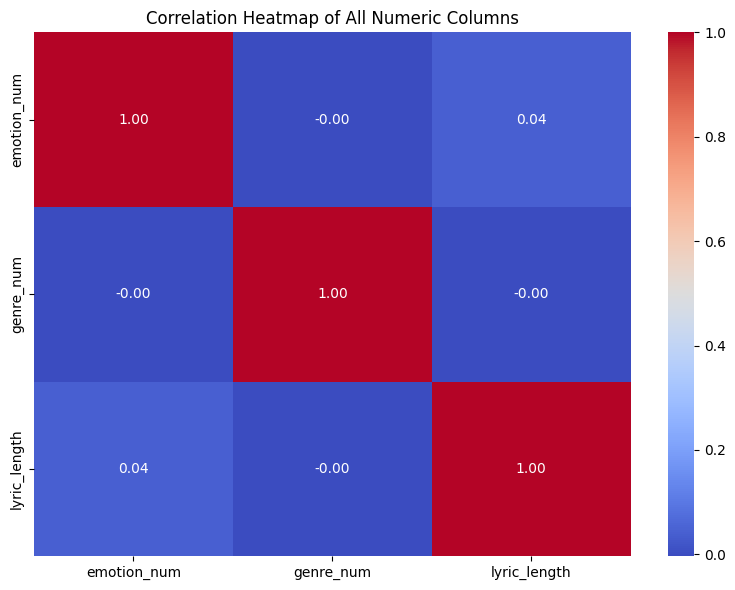

In [ ]:
emotion_map = {'positive': 1, 'neutral': 0, 'negative': -1}
genre_map = {genre: i for i, genre in enumerate(df_reconstructed['genre'].unique())}

df_reconstructed['emotion_num'] = df_reconstructed['emotion'].map(emotion_map)
df_reconstructed['genre_num'] = df_reconstructed['genre'].map(genre_map)

df_reconstructed['lyric_length'] = df_reconstructed['lyrics'].apply(lambda x: len(str(x).split()))

numeric_cols = df_reconstructed.select_dtypes(include=['number'])
correlation_matrix = numeric_cols.corr()
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of All Numeric Columns")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

genres = ['pop', 'rock', 'hiphop']
np.random.seed(42)
df_reconstructed['genre'] = np.random.choice(genres, size=len(df_reconstructed))

df_reconstructed[['track_id', 'lyrics', 'genre']].head()

,track_id,lyrics,genre
0,TRAAAAV128F421A322,i i i i i i the the the the you you to to and ...,hiphop
1,TRAAABD128F429CF47,i i i i i i i i i i you you you you you you yo...,pop
2,TRAAAED128E0783FAB,i i i i i i i i i i i i i i i i i i i i i i i ...,hiphop
3,TRAAAEF128F4273421,i i i i i the the the the you you you to to an...,hiphop
4,TRAAAEW128F42930C0,i i i i to to to to to and and and and and and...,pop


In [ ]:
from sklearn.model_selection import train_test_split
from datasets import Dataset

df_genre = df_reconstructed[['lyrics', 'genre']].dropna()

train_df, test_df = train_test_split(df_genre, test_size=0.2, random_state=42)

train_ds = Dataset.from_pandas(train_df)
test_ds = Dataset.from_pandas(test_df)

In [ ]:
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

label2id = {label: i for i, label in enumerate(genres)}
id2label = {i: label for label, i in label2id.items()}

def tokenize(example):
    tokens = tokenizer(example['lyrics'], truncation=True, padding='max_length', max_length=128)
    tokens['labels'] = label2id[example['genre']]
    return tokens

train_ds = train_ds.map(tokenize)
test_ds = test_ds.map(tokenize)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Map:   0%|          | 0/168415 [00:00<?, ? examples/s]

Map:   0%|          | 0/42104 [00:00<?, ? examples/s]

In [ ]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(genres),
    id2label=id2label,
    label2id=label2id
)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
import transformers
print(transformers.__version__)

4.51.3


In [ ]:
!pip install transformers datasets scikit-learn

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    weight_decay=0.01,
    learning_rate=5e-5,

    warmup_steps=500,
    logging_dir="./logs",
    logging_steps=20,

    report_to="none"
)

In [ ]:
from sklearn.metrics import accuracy_score

def compute_metrics(pred):
    predictions = pred.predictions.argmax(-1)
    labels = pred.label_ids
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc}

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

<ipython-input-30-1ba72d687705>:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
import os
os.environ["WANDB_MODE"] = "disabled"
from transformers import Trainer
Trainer._wandb = None

import wandb
wandb.init = lambda *args, **kwargs: None
wandb.log = lambda *args, **kwargs: None
wandb.watch = lambda *args, **kwargs: None
wandb.finish = lambda *args, **kwargs: None


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,1.100100,1.098828,0.332510
2,1.098400,1.098891,0.332510
3,1.099800,1.098691,0.333626
4,1.098400,1.098611,0.333864
5,1.098600,1.098629,0.333626


TrainOutput(global_step=105260, training_loss=1.0992879872989818, metrics={'train_runtime': 3328.5013, 'train_samples_per_second': 252.989, 'train_steps_per_second': 31.624, 'total_flos': 2.78873685035712e+16, 'train_loss': 1.0992879872989818, 'epoch': 5.0})

In [ ]:
model.save_pretrained("./trained_model")
tokenizer.save_pretrained("./trained_model")
trainer.evaluate(test_ds)
predictions = trainer.predict(test_ds)

In [ ]:
import numpy as np

predicted_logits = predictions.predictions
predicted_labels = np.argmax(predicted_logits, axis=1)

print("Predicted Labels:", predicted_labels[:10])
print("True Labels     :", predictions.label_ids[:10])

Predicted Labels: [1 1 1 1 1 1 1 1 1 1]
True Labels     : [1 1 0 0 2 0 2 1 1 1]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(predictions.label_ids, predicted_labels)
print("Test Accuracy:", accuracy)


Test Accuracy: 0.3338637659129774


In [ ]:
from datasets import load_dataset
ds = load_dataset("ailsntua/Chordonomicon")

In [ ]:
ds['train'].features
ds['train'].to_pandas().head(5)

,id,chords,release_date,genres,decade,rock_genre,artist_id,main_genre,spotify_song_id,spotify_artist_id
0,1,<intro_1> C <verse_1> F C E7 Amin C F C G7 C F...,None,'classic country pop',NaN,None,artist_1,pop,None,4AIEGdwDzPELXYgM5JaEY5
1,2,<intro_1> E D A/Cs E D A/Cs <verse_1> E D A/Cs...,2003-01-01,'alternative metal' 'alternative rock' 'nu met...,2000.0,pop rock,artist_2,metal,2ffJZ2r8HxI5DHcmf3BO6c,694QW15WkebjcrWgQHzRYF
2,3,<intro_1> Csmin <verse_1> A Csmin A Csmin A Cs...,2003-01-01,'alternative metal' 'canadian rock' 'funk meta...,2000.0,canadian rock,artist_3,metal,5KiY8SZEnvCPyIEkFGRR3y,0niJkG4tKkne3zwr7I8n9n
3,4,<intro_1> D Dmaj7 D Dmaj7 <verse_1> Emin A D G...,2022-09-23,None,2020.0,None,artist_4,None,01TtAcUqyLCRBZq4ZZiQWS,17BfKBemmMGO5ZAK25wraW
4,5,<intro_1> C <verse_1> G C G C <chorus_1> F Dmi...,2023-02-10,'modern country pop',2020.0,None,artist_5,pop,3zUecdrWC3IqrNSjhnoF3G,4GGfAshSkqoxpZdoaHm7ky


In [ ]:
!mkdir -p /content/drive/MyDrive/gpt2_project_backup
!cp -r /content/results /content/drive/MyDrive/gpt2_project_backup/
!cp -r /content/trained_model /content/drive/MyDrive/gpt2_project_backup/


In [ ]:
import pandas as pd
chord_df = ds['train'].to_pandas()

chord_df = chord_df[chord_df['chords'].notnull() & chord_df['genres'].notnull()]

chord_df['text'] = "Genre: " + chord_df['genres'] + "\nChords:\n" + chord_df['chords']

chord_df[['text']].head()

,text
0,Genre: 'classic country pop'\nChords:\n<intro_...
1,Genre: 'alternative metal' 'alternative rock' ...
2,Genre: 'alternative metal' 'canadian rock' 'fu...
4,Genre: 'modern country pop'\nChords:\n<intro_1...
5,Genre: 'classic opm' 'opm'\nChords:\n<intro_1>...


In [ ]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

model = GPT2LMHeadModel.from_pretrained("gpt2")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
from datasets import Dataset

hf_dataset = Dataset.from_pandas(chord_df[['text']])

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)

tokenized_dataset = hf_dataset.map(tokenize_fn, batched=True)

Map:   0%|          | 0/429753 [00:00<?, ? examples/s]

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [ ]:
from transformers import Trainer, TrainingArguments, DataCollatorForLanguageModeling

training_args = TrainingArguments(
    output_dir="./gpt2-chord-gen",
    per_device_train_batch_size=2,
    num_train_epochs=2,
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=1000,
)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    data_collator=data_collator,
)

trainer.train()

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Step,Training Loss
1000,0.755700
2000,0.706900
3000,0.707700
4000,0.738800
5000,0.742600
6000,0.731500
7000,0.726700
8000,0.717900
9000,0.718900
10000,0.707900


TrainOutput(global_step=429754, training_loss=0.6001634329309571, metrics={'train_runtime': 16236.0604, 'train_samples_per_second': 52.938, 'train_steps_per_second': 26.469, 'total_flos': 5.6145517314048e+16, 'train_loss': 0.6001634329309571, 'epoch': 2.0})

In [ ]:
!zip -r checkpoint-429754.zip gpt2-chord-gen/checkpoint-429754

  adding: gpt2-chord-gen/checkpoint-429754/ (stored 0%)
  adding: gpt2-chord-gen/checkpoint-429754/rng_state.pth (deflated 25%)
  adding: gpt2-chord-gen/checkpoint-429754/special_tokens_map.json (deflated 74%)
  adding: gpt2-chord-gen/checkpoint-429754/vocab.json (deflated 68%)
  adding: gpt2-chord-gen/checkpoint-429754/scheduler.pt (deflated 56%)
  adding: gpt2-chord-gen/checkpoint-429754/config.json (deflated 51%)
  adding: gpt2-chord-gen/checkpoint-429754/model.safetensors (deflated 7%)
  adding: gpt2-chord-gen/checkpoint-429754/training_args.bin (deflated 51%)
  adding: gpt2-chord-gen/checkpoint-429754/optimizer.pt (deflated 9%)
  adding: gpt2-chord-gen/checkpoint-429754/merges.txt (deflated 53%)
  adding: gpt2-chord-gen/checkpoint-429754/trainer_state.json (deflated 78%)
  adding: gpt2-chord-gen/checkpoint-429754/generation_config.json (deflated 24%)
  adding: gpt2-chord-gen/checkpoint-429754/tokenizer_config.json (deflated 56%)


In [ ]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel

model_path = "gpt2-chord-gen/checkpoint-429754"

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained(model_path)
model.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [ ]:
def generate_chords_from_lyrics(lyrics_prompt, max_length=100):
    inputs = tokenizer(lyrics_prompt, return_tensors="pt")
    outputs = model.generate(
        **inputs,
        max_length=max_length,
        num_return_sequences=1,
        temperature=0.7,
        top_p=0.9,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [ ]:
prompt = "When the night falls and the stars light the sky,"
output = generate_chords_from_lyrics(prompt)
print(" Generated Chords + Lyrics:\n")
print(output)

 Generated Chords + Lyrics:

When the night falls and the stars light the sky,'
Chords:
<verse_1> Bb F C Bb F C Bb F C Bb F C <chorus_1> Bb F C Bb F C Bb F C Bb F C Bb F C Bb F C <verse_2> Bb F C Bb F C Bb F C Bb F C <chorus_2> Bb F C B


In [ ]:
with open("generated_output.txt", "w") as f:
    f.write(output)

In [ ]:
!pip install pretty_midi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 66.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.5 MB/s eta 0:00:00
  Created wheel for pretty_midi: filename=pretty_midi-0.2.10-py3-none-any.whl size=5592286 sha256=2e60effa24d799b00714aeea778ca134ac1694cdafbbb325777ee3360a324d86
  Stored in directory: /root/.cache/pip/wheels/e6/95/ac/15ceaeb2823b04d8e638fd1495357adb8d26c00ccac9d7782e
Successfully built pretty_midi


In [ ]:
import pretty_midi

def chord_to_notes(chord):
    mapping = {
        "C": ["C4", "E4", "G4"], "C#": ["C#4", "F4", "G#4"],
        "D": ["D4", "F#4", "A4"], "Eb": ["Eb4", "G4", "Bb4"],
        "E": ["E4", "G#4", "B4"], "F": ["F4", "A4", "C5"],
        "F#": ["F#4", "A#4", "C#5"], "G": ["G4", "B4", "D5"],
        "Ab": ["Ab4", "C5", "Eb5"], "A": ["A4", "C#5", "E5"],
        "Bb": ["Bb4", "D5", "F5"], "B": ["B4", "D#5", "F#5"]
    }
    return mapping.get(chord, [])

def generate_midi_from_chords(chord_sequence, output_file="generated_chords.mid"):

    midi = pretty_midi.PrettyMIDI()
    piano = pretty_midi.Instrument(program=0)

    chords = chord_sequence.split()
    start = 0
    duration = 1.0

    for chord in chords:
        notes = chord_to_notes(chord)
        for note_name in notes:
            note_number = pretty_midi.note_name_to_number(note_name)
            note = pretty_midi.Note(velocity=100, pitch=note_number, start=start, end=start + duration)
            piano.notes.append(note)
        start += duration

    midi.instruments.append(piano)
    midi.write(output_file)
    print(f"MIDI saved to: {output_file}")

In [ ]:
import re

def clean_chord_string(raw_output):
    cleaned = re.sub(r"<[^>]+>", "", raw_output)

    cleaned = re.sub(r"\s+", " ", cleaned).strip()
    return cleaned

In [ ]:
raw_chords = "<verse_1> Bb F C Bb F C Bb F C Bb F C <chorus_1> Bb F C Bb F C Bb F C Bb F C <verse_2> Bb F C Bb F C Bb F C <chorus_2> Bb F C B"
cleaned_chords = clean_chord_string(raw_chords)
print("Cleaned Chords:", cleaned_chords)

Cleaned Chords: Bb F C Bb F C Bb F C Bb F C Bb F C Bb F C Bb F C Bb F C Bb F C Bb F C Bb F C Bb F C B


In [ ]:
generate_midi_from_chords(cleaned_chords, "generated_output.mid")

MIDI saved to: generated_output.mid


In [ ]:
from IPython.display import Audio
import sys

!apt install -y fluidsynth
!pip install midi2audio
from midi2audio import FluidSynth

fs = FluidSynth()
fs.midi_to_audio("generated_output.mid", "output.wav")
Audio("output.wav")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fluid-soundfont-gm libevdev2 libfluidsynth3 libgudev-1.0-0 libinput-bin
  libinput10 libinstpatch-1.0-2 libmd4c0 libmtdev1 libqt5core5a libqt5dbus5
  libqt5gui5 libqt5network5 libqt5svg5 libqt5widgets5 libwacom-bin
  libwacom-common libwacom9 libxcb-icccm4 libxcb-image0 libxcb-keysyms1
  libxcb-render-util0 libxcb-util1 libxcb-xinerama0 libxcb-xinput0 libxcb-xkb1
  libxkbcommon-x11-0 qsynth qt5-gtk-platformtheme qttranslations5-l10n
  timgm6mb-soundfont
Suggested packages:
  fluid-soundfont-gs qt5-image-formats-plugins qtwayland5 jackd
The following NEW packages will be installed:
  fluid-soundfont-gm fluidsynth libevdev2 libfluidsynth3 libgudev-1.0-0
  libinput-bin libinput10 libinstpatch-1.0-2 libmd4c0 libmtdev1 libqt5core5a
  libqt5dbus5 libqt5gui5 libqt5network5 libqt5svg5 libqt5widgets5 libwacom-bin
  libwacom-common libwacom9 libx

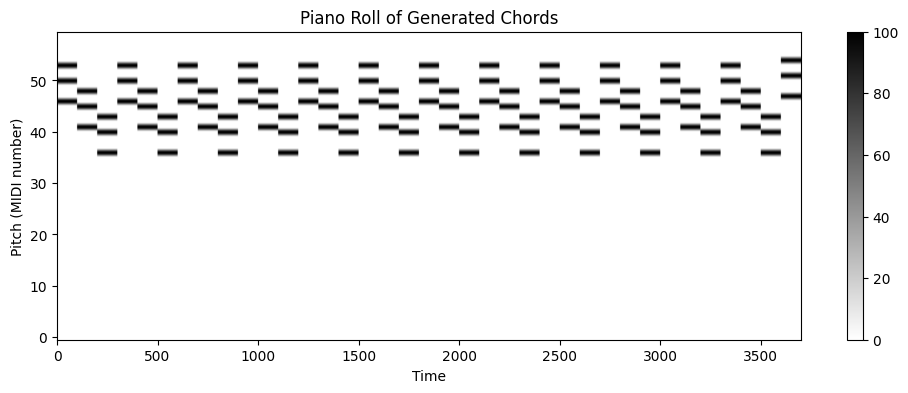

In [ ]:
import pretty_midi
import matplotlib.pyplot as plt

midi_data = pretty_midi.PrettyMIDI("generated_output.mid")

plt.figure(figsize=(12, 4))
plt.imshow(midi_data.get_piano_roll()[24:84], aspect='auto', origin='lower', cmap='gray_r')
plt.title("Piano Roll of Generated Chords")
plt.xlabel("Time")
plt.ylabel("Pitch (MIDI number)")
plt.colorbar()
plt.show()

In [ ]:
from transformers import pipeline

lyrics = "When the night falls and the stars light the sky"
chords = "Bb F C Bb F C Bb F C Bb F C Bb F C Bb F C B"

eval_prompt = f"""
Evaluate how well the following chords match the emotional tone and lyrical flow of the lyrics.

Lyrics:
"{lyrics}"

Chords:
"{chords}"

Give a score from 1 to 10 and a brief explanation of your reasoning.
"""

generator = pipeline("text-generation", model="tiiuae/falcon-7b-instruct", device_map="auto")

response = generator(eval_prompt, max_length=200, do_sample=False)[0]["generated_text"]

print(" LLM Evaluation Result:\n")
print(response)

config.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/17.7k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.95G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.48G [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.13k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.73M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/281 [00:00<?, ?B/s]

Device set to use cuda:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:11 for open-end generation.


 LLM Evaluation Result:


Evaluate how well the following chords match the emotional tone and lyrical flow of the lyrics.

Lyrics:
"When the night falls and the stars light the sky"

Chords:
"Bb F C Bb F C Bb F C Bb F C Bb F C Bb F C B"

Give a score from 1 to 10 and a brief explanation of your reasoning.

Score: 8 - The chords match the emotional tone and lyrical flow of the lyrics. The Bb chord creates a minor key, which is often associated with sadness or melancholy. The F chord is a major chord, which can evoke feelings of happiness or excitement. The C and B chords are both bright and cheerful, which contrasts with the minor key. The F chord in the second line creates a sense of resolution and hope, which is a positive emotion.


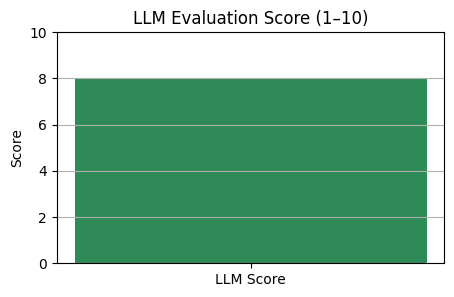

In [ ]:
import re
import matplotlib.pyplot as plt

response_text = """
Score: 8 - The chords match the emotional tone and lyrical flow of the lyrics.
The Bb chord creates a minor key, which is often associated with sadness or melancholy.
The F chord is a major chord, which can evoke feelings of happiness or excitement.
"""

match = re.search(r"Score:\s*([0-9]+)", response_text)
score = int(match.group(1)) if match else 5

plt.figure(figsize=(5, 3))
plt.bar(["LLM Score"], [score], color="seagreen")
plt.ylim(0, 10)
plt.title("LLM Evaluation Score (1–10)")
plt.ylabel("Score")
plt.grid(axis="y")
plt.show()

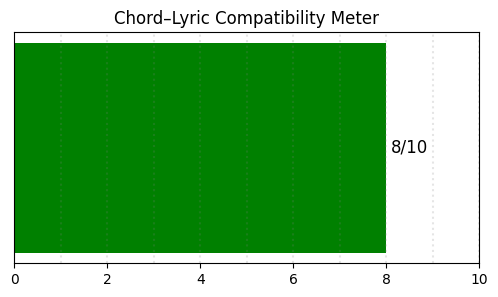

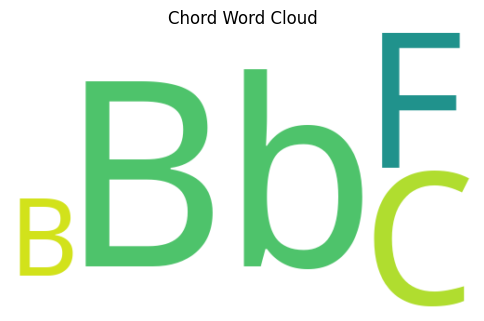

LLM Evaluation Summary
 Lyrics: "When the night falls and the stars light the sky"
 Chords: Bb F C Bb F C Bb F C Bb F C Bb F C Bb F C B
 Score: 8/10


In [ ]:

from wordcloud import WordCloud
import numpy as np

lyrics = "When the night falls and the stars light the sky"
chords = "Bb F C Bb F C Bb F C Bb F C Bb F C Bb F C B"
score = 8

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(0, score, color="green", height=0.3)
ax.set_xlim(0, 10)
ax.set_yticks([])
ax.set_title("Chord–Lyric Compatibility Meter")
for i in range(11):
    ax.axvline(i, color="gray", linestyle=":", alpha=0.2)
ax.text(score + 0.1, 0, f"{score}/10", fontsize=12, va='center')
plt.show()

wordcloud = WordCloud(width=500, height=300, background_color="white").generate(chords)
plt.figure(figsize=(6, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Chord Word Cloud")
plt.show()

print("LLM Evaluation Summary")
print(f" Lyrics: \"{lyrics}\"")
print(f" Chords: {chords}")
print(f" Score: {score}/10")

In [ ]:
import os

project_path = "/content/drive/MyDrive/My_Music_Project"
os.makedirs(project_path, exist_ok=True)
print(f"Saved outputs will go to: {project_path}")

Saved outputs will go to: /content/drive/MyDrive/My_Music_Project


In [ ]:
with open(f"{project_path}/generated_chords.txt", "w") as f:
    for i, chords in enumerate(chord_versions, 1):
        f.write(f"Version {i}:\n{chords}\n\n")
with open(f"{project_path}/llm_evaluation_results.txt", "w") as f:
    f.write(response['generated_text'] if isinstance(response, dict) else str(response))
plt.savefig(f"{project_path}/llm_score_plot.png")
plt.show()